# 📊 Bitcoin Fear & Greed vs Trader Performance
### Hyperliquid Historical Trade Analysis

> **Assignment:** Explore the relationship between market sentiment and trader performance,  
> uncover hidden patterns, and deliver insights that can drive smarter trading strategies.

---

| Dataset | Rows | Description |
|---|---|---|
| `historical_data.csv` | 211,224 | Real trades from Hyperliquid exchange |
| `fear_greed_index.csv` | 2,644 | Daily Bitcoin Fear & Greed scores (2018–2025) |

**Key question:** Does market sentiment (Fear vs Greed) affect how traders behave and how much money they make?


## ⚙️ Step 0 — Install & Import Libraries

In [1]:
# Install required libraries (run once)
# !pip install pandas matplotlib seaborn scipy plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── Plot style ──
BG    = "#0d0d18"
PANEL = "#13131f"
TEXT  = "#e8e8f0"
GRID  = "#1e1e32"

plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "font.size":          11,
    "text.color":         TEXT,
    "axes.labelcolor":    TEXT,
    "xtick.color":        TEXT,
    "ytick.color":        TEXT,
    "axes.edgecolor":     GRID,
    "axes.facecolor":     PANEL,
    "figure.facecolor":   BG,
    "grid.color":         GRID,
    "grid.linewidth":     0.5,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
})

print("✅ Libraries imported successfully")


✅ Libraries imported successfully


## 📂 Step 1 — Load the Datasets

In [2]:
# ── Load both CSVs ──
# Make sure both files are in the same folder as this notebook
trader    = pd.read_csv("../data/historical_data.csv")
sentiment = pd.read_csv("../data/fear_greed_index.csv")

print(f"✅ Trader data    : {trader.shape[0]:,} rows × {trader.shape[1]} columns")
print(f"✅ Sentiment data : {sentiment.shape[0]:,} rows × {sentiment.shape[1]} columns")
print()
print("Trader columns   :", list(trader.columns))
print("Sentiment columns:", list(sentiment.columns))


✅ Trader data    : 211,224 rows × 16 columns
✅ Sentiment data : 2,644 rows × 4 columns

Trader columns   : ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
Sentiment columns: ['timestamp', 'value', 'classification', 'date']


### 👀 Quick Preview

In [3]:
print("── Trader Data (first 3 rows) ──")
display(trader.head(3))
print()
print("── Sentiment Data (first 3 rows) ──")
display(sentiment.head(3))


── Trader Data (first 3 rows) ──


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12



── Sentiment Data (first 3 rows) ──


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03


## 🧹 Step 2 — Clean & Prepare Data

In [4]:
# ── Trader: parse date from 'Timestamp IST' (format: DD-MM-YYYY HH:MM) ──
trader['date'] = pd.to_datetime(trader['Timestamp IST'], dayfirst=True).dt.normalize()

# ── Convert numeric columns ──
for col in ['Closed PnL', 'Size USD', 'Size Tokens', 'Execution Price', 'Fee']:
    trader[col] = pd.to_numeric(trader[col], errors='coerce')

# ── Helper boolean columns ──
trader['is_long']   = trader['Side'].str.upper() == 'BUY'          # BUY = Long
trader['is_closed'] = trader['Closed PnL'] != 0                    # Trade exited
trader['is_win']    = trader['Closed PnL'] > 0                     # Profitable trade

# ── Sentiment: parse date ──
sentiment['date']  = pd.to_datetime(sentiment['date']).dt.normalize()
sentiment['value'] = pd.to_numeric(sentiment['value'], errors='coerce')

# ── Only closed trades for PnL analysis ──
closed = trader[trader['is_closed']].copy()

print(f"Total trades       : {len(trader):,}")
print(f"Open positions     : {(~trader['is_closed']).sum():,}  (Closed PnL = 0)")
print(f"Closed trades      : {len(closed):,}  (used for PnL analysis)")
print(f"Unique traders     : {trader['Account'].nunique()}")
print(f"Unique coins       : {trader['Coin'].nunique()}")
print(f"Trader date range  : {trader['date'].min().date()} → {trader['date'].max().date()}")
print(f"Sentiment date range: {sentiment['date'].min().date()} → {sentiment['date'].max().date()}")


Total trades       : 211,224
Open positions     : 106,816  (Closed PnL = 0)
Closed trades      : 104,408  (used for PnL analysis)
Unique traders     : 32
Unique coins       : 246
Trader date range  : 2023-05-01 → 2025-05-01
Sentiment date range: 2018-02-01 → 2025-05-02


## 🔗 Step 3 — Merge Datasets on Date

In [5]:
# ── Join trader trades with sentiment by date ──
merged = pd.merge(
    trader,
    sentiment[['date', 'value', 'classification']].drop_duplicates('date'),
    on='date',
    how='inner'
)

closed_m = merged[merged['is_closed']].copy()

# ── Sentiment order for charts ──
ORDER = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
COLORS = {
    "Extreme Fear":  "#e63946",
    "Fear":          "#f4a261",
    "Neutral":       "#adb5bd",
    "Greed":         "#52b788",
    "Extreme Greed": "#2dc653"
}
palette = [COLORS[s] for s in ORDER]

print(f"✅ Merged rows: {len(merged):,}")
print()
print("Sentiment distribution in merged data:")
print(merged['classification'].value_counts().reindex(ORDER))


✅ Merged rows: 211,218

Sentiment distribution in merged data:
classification
Extreme Fear     21400
Fear             61837
Neutral          37686
Greed            50303
Extreme Greed    39992
Name: count, dtype: int64


## 📐 Step 4 — Compute Key Metrics by Sentiment

In [6]:
# ── All trades aggregated by sentiment ──
by_sent = merged.groupby('classification').agg(
    trade_count  = ('Closed PnL', 'count'),
    total_volume = ('Size USD',   'sum'),
    avg_size     = ('Size USD',   'mean'),
    total_pnl    = ('Closed PnL', 'sum'),
    avg_pnl      = ('Closed PnL', 'mean'),
    total_fees   = ('Fee',        'sum'),
    long_ratio   = ('is_long',    'mean'),
).reindex(ORDER)

# ── Closed trades only ──
by_sent_closed = closed_m.groupby('classification').agg(
    win_rate    = ('is_win',    'mean'),
    avg_pnl_c   = ('Closed PnL','mean'),
    total_pnl_c = ('Closed PnL','sum'),
).reindex(ORDER)

# ── Daily aggregation for correlation ──
daily = merged.groupby('date').agg(
    avg_pnl       = ('Closed PnL', 'mean'),
    sentiment_val = ('value',       'mean'),
    classification= ('classification','first')
).dropna()

# ── Print summary table ──
summary = pd.concat([by_sent, by_sent_closed], axis=1)
summary['win_rate_pct'] = (summary['win_rate'] * 100).round(1)
summary['long_pct']     = (summary['long_ratio'] * 100).round(1)
summary['vol_M']        = (summary['total_volume'] / 1e6).round(1)

display(summary[['trade_count','vol_M','win_rate_pct','avg_pnl_c','long_pct','total_fees']].rename(columns={
    'trade_count' : 'Trades',
    'vol_M'       : 'Volume ($M)',
    'win_rate_pct': 'Win Rate (%)',
    'avg_pnl_c'   : 'Avg PnL ($)',
    'long_pct'    : 'Long Ratio (%)',
    'total_fees'  : 'Total Fees ($)',
}))


,Trades,Volume ($M),Win Rate (%),Avg PnL ($),Long Ratio (%),Total Fees ($)
classification,,,,,,
Extreme Fear,21400,114.5,76.2,71.027316,51.1,23888.633939
Fear,61837,483.3,87.3,112.625988,49.0,92456.948674
Neutral,37686,180.2,82.4,71.199993,50.3,39374.268304
Greed,50303,288.6,76.9,85.403927,48.9,63098.691979
Extreme Greed,39992,124.5,89.2,130.205309,44.9,27030.665465


## 🔬 Step 5 — Statistical Correlation Test

In [7]:
# ── Pearson correlation: sentiment score vs average daily PnL ──
corr, pval = stats.pearsonr(daily['sentiment_val'], daily['avg_pnl'])

print("=" * 50)
print("  Pearson Correlation Test")
print("=" * 50)
print(f"  Sentiment Score  vs  Avg Daily PnL")
print(f"  r (correlation)  = {corr:.4f}")
print(f"  p-value          = {pval:.4f}")
print()
if pval < 0.05:
    direction = "positive" if corr > 0 else "negative"
    print(f"  ✅ Statistically significant {direction} correlation (p < 0.05)")
else:
    print("  ⚠️  Not statistically significant (p > 0.05)")
    print("  → Sentiment score alone does NOT reliably predict daily PnL")
    print("  → Trader skill matters more than market mood")
print("=" * 50)


  Pearson Correlation Test
  Sentiment Score  vs  Avg Daily PnL
  r (correlation)  = 0.0373
  p-value          = 0.4152

  ⚠️  Not statistically significant (p > 0.05)
  → Sentiment score alone does NOT reliably predict daily PnL
  → Trader skill matters more than market mood


## 📊 Step 6 — Visualisations

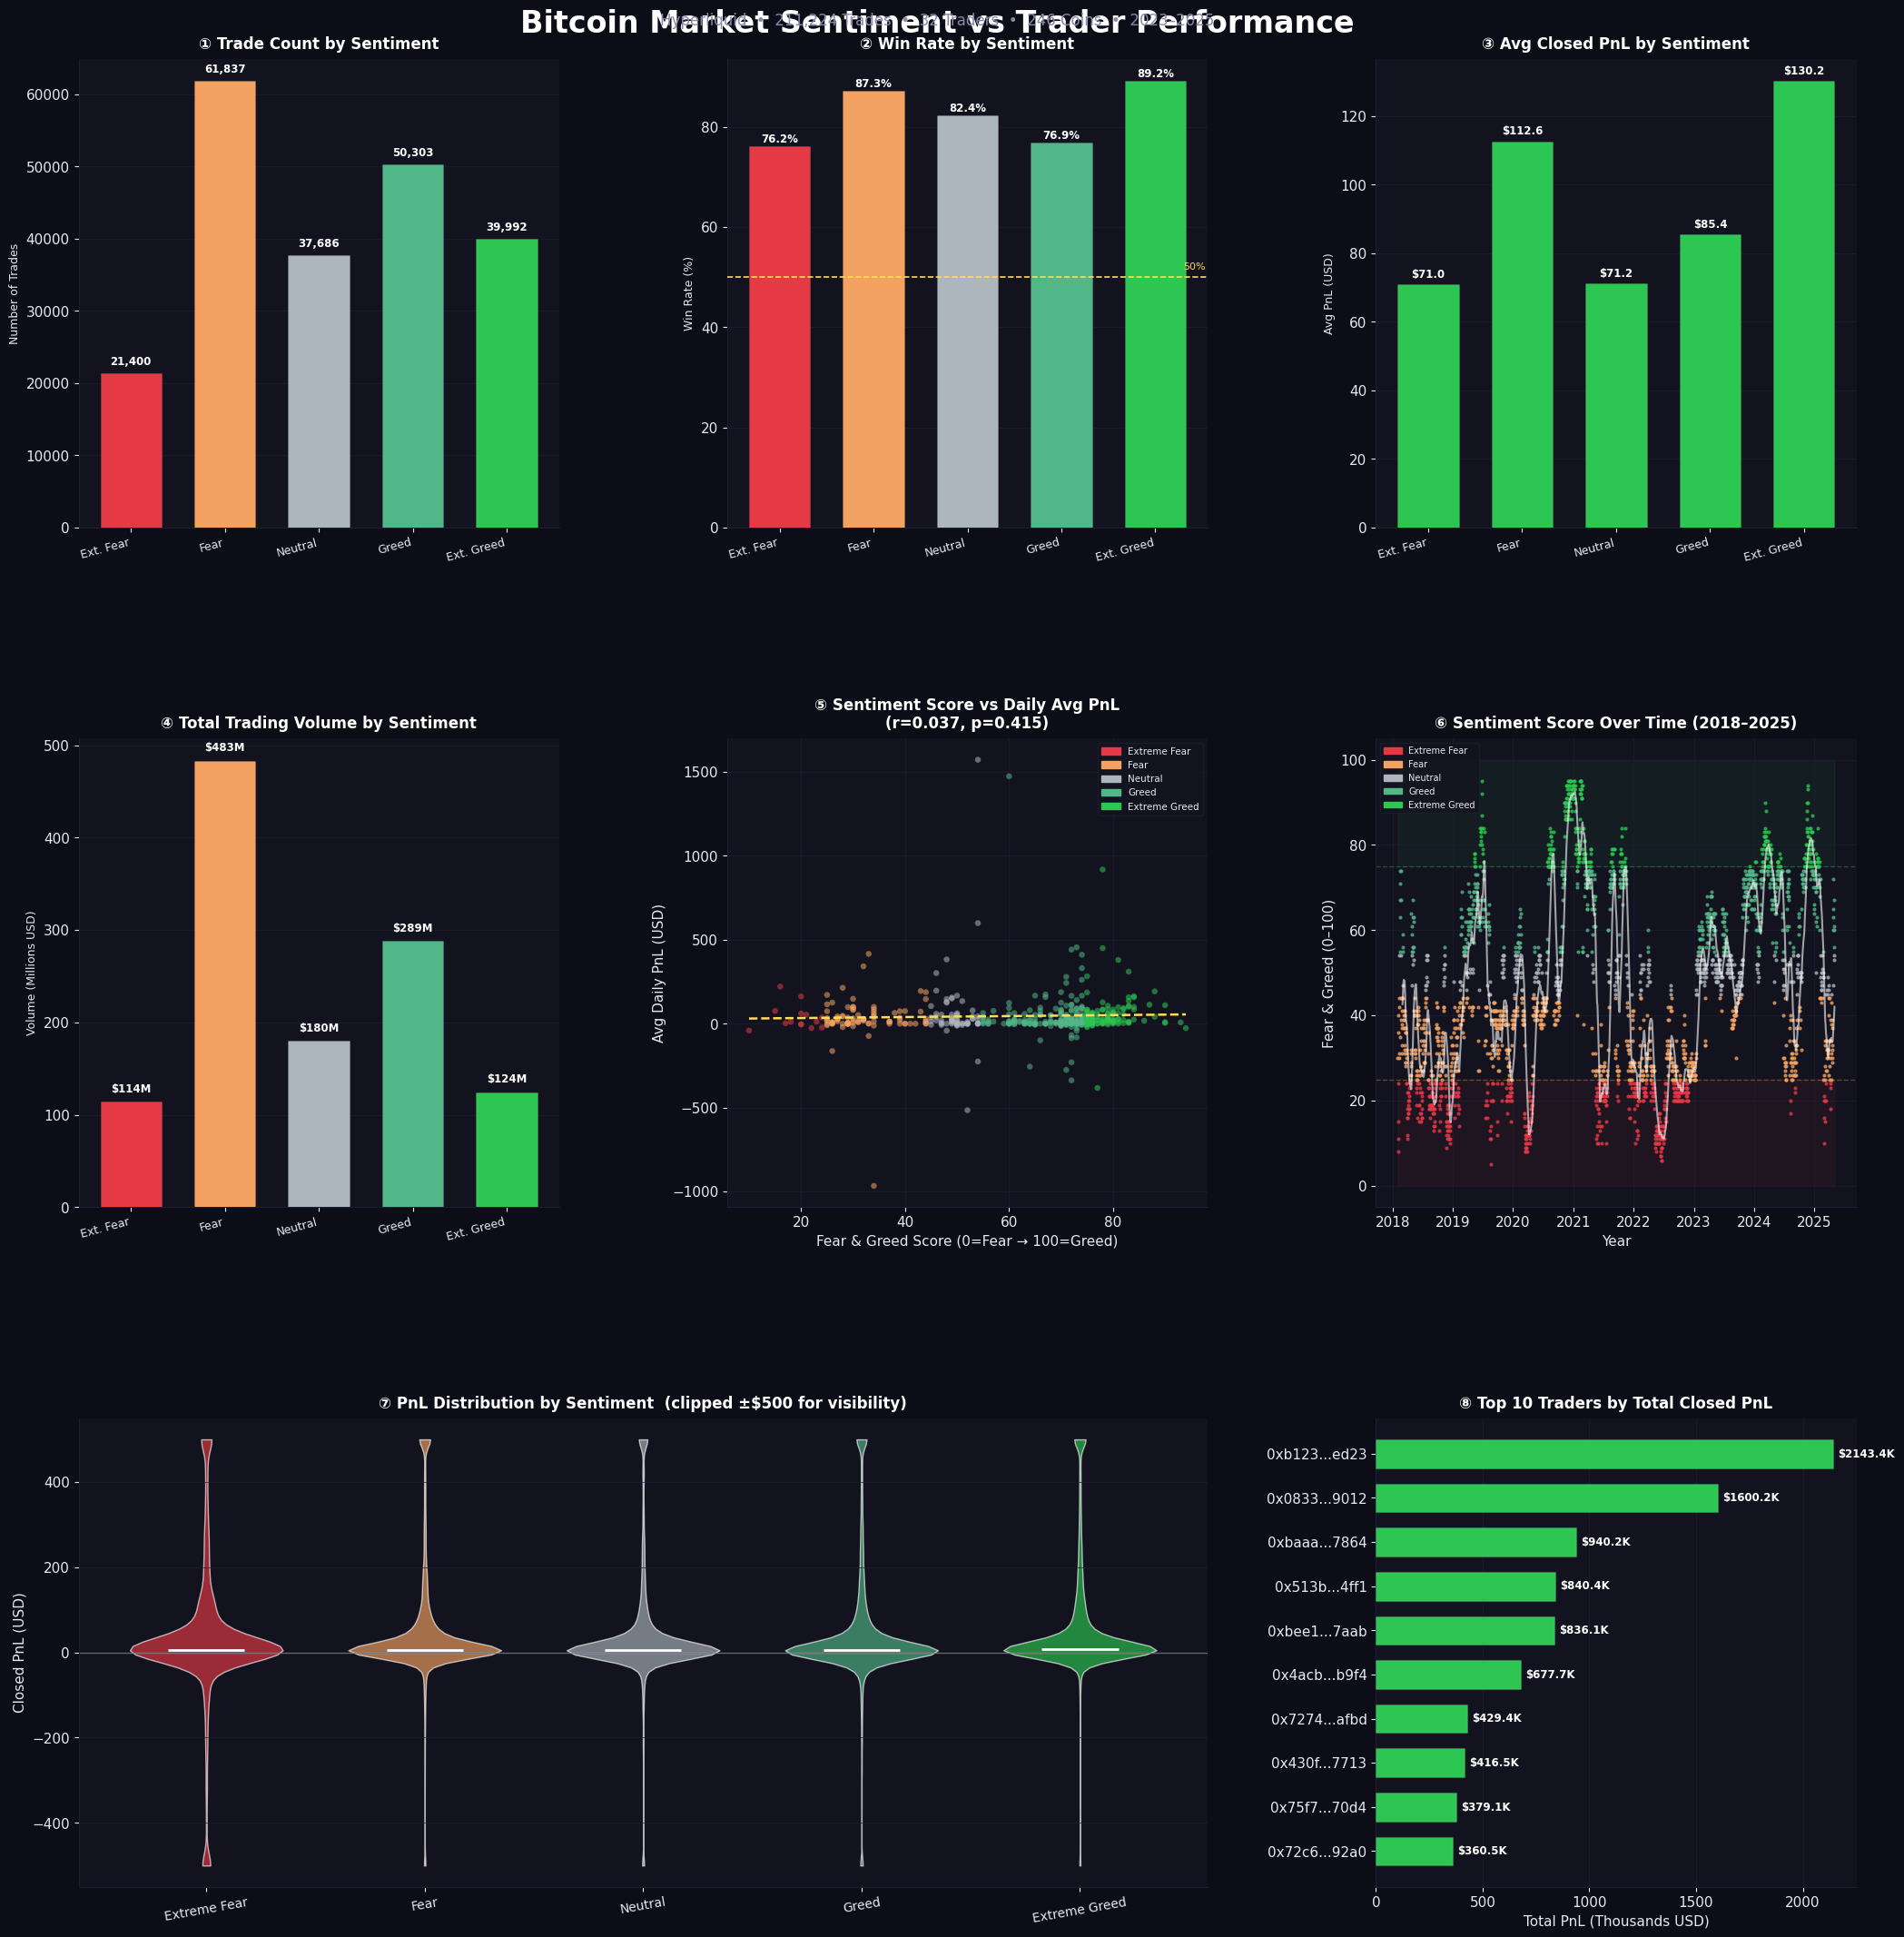

✅ Chart saved as trading_sentiment_analysis.png


In [8]:
SHORT = ["Ext. Fear", "Fear", "Neutral", "Greed", "Ext. Greed"]

def bar_chart(ax, vals, title, ylabel, colors=palette, fmt="{:.1f}", add_zero=True):
    x = np.arange(len(ORDER))
    bars = ax.bar(x, vals, color=colors, width=0.65,
                  edgecolor='#ffffff18', linewidth=0.6, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(SHORT, fontsize=9, rotation=15, ha='right')
    ax.set_title(title, fontsize=12, fontweight='bold', color='#ffffff', pad=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(axis='y', zorder=0)
    if add_zero:
        ax.axhline(0, color='#ffffff33', linewidth=0.8)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            offset = (max(vals) - min(vals)) * 0.02
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + offset,
                    fmt.format(v), ha='center', va='bottom',
                    fontsize=8.5, color='#ffffff', fontweight='bold')

fig = plt.figure(figsize=(22, 22), facecolor=BG)
fig.suptitle(
    "Bitcoin Market Sentiment vs Trader Performance",
    fontsize=24, fontweight='bold', color='#ffffff', y=0.98
)
fig.text(0.5, 0.972,
    "Hyperliquid  \u2022  211,224 Trades  \u2022  32 Traders  \u2022  246 Coins  \u2022  2023\u20132025",
    ha='center', fontsize=12, color='#8888aa'
)

gs = gridspec.GridSpec(3, 3, figure=fig,
    hspace=0.45, wspace=0.35,
    top=0.955, bottom=0.04, left=0.07, right=0.96)

# \u2500\u2500 1. Trade Count \u2500\u2500
ax1 = fig.add_subplot(gs[0, 0])
bar_chart(ax1, by_sent['trade_count'].values,
          "\u2460 Trade Count by Sentiment", "Number of Trades",
          fmt="{:,.0f}", add_zero=False)

# \u2500\u2500 2. Win Rate \u2500\u2500
ax2 = fig.add_subplot(gs[0, 1])
wr_vals = (by_sent_closed['win_rate'] * 100).values
bar_chart(ax2, wr_vals, "\u2461 Win Rate by Sentiment", "Win Rate (%)", fmt="{:.1f}%", add_zero=False)
ax2.axhline(50, color='#ffdd57', linewidth=1.2, linestyle='--', zorder=4)
ax2.text(4.3, 51.5, "50%", color='#ffdd57', fontsize=8)

# \u2500\u2500 3. Avg Closed PnL \u2500\u2500
ax3 = fig.add_subplot(gs[0, 2])
pnl_vals = by_sent_closed['avg_pnl_c'].values
pnl_colors = ['#2dc653' if v >= 0 else '#e63946' for v in pnl_vals]
bar_chart(ax3, pnl_vals, "\u2462 Avg Closed PnL by Sentiment",
          "Avg PnL (USD)", colors=pnl_colors, fmt="${:.1f}")

# \u2500\u2500 4. Total Volume \u2500\u2500
ax4 = fig.add_subplot(gs[1, 0])
vol_vals = by_sent['total_volume'].values / 1e6
bar_chart(ax4, vol_vals, "\u2463 Total Trading Volume by Sentiment",
          "Volume (Millions USD)", fmt="${:.0f}M", add_zero=False)

# \u2500\u2500 5. Scatter: Sentiment score vs daily avg PnL \u2500\u2500
ax5 = fig.add_subplot(gs[1, 1])
for s in ORDER:
    d = daily[daily['classification'] == s]
    ax5.scatter(d['sentiment_val'], d['avg_pnl'],
                color=COLORS[s], alpha=0.55, s=22, edgecolors='none', label=s, zorder=3)
m, b, r, p, _ = stats.linregress(daily['sentiment_val'], daily['avg_pnl'])
xs = np.linspace(daily['sentiment_val'].min(), daily['sentiment_val'].max(), 100)
ax5.plot(xs, m*xs+b, color='#ffdd57', linewidth=1.8, linestyle='--', zorder=4)
ax5.set_title(f"\u2464 Sentiment Score vs Daily Avg PnL\n(r={r:.3f}, p={p:.3f})",
              fontsize=12, fontweight='bold', color='#ffffff', pad=8)
ax5.set_xlabel("Fear & Greed Score (0=Fear \u2192 100=Greed)")
ax5.set_ylabel("Avg Daily PnL (USD)"); ax5.grid(zorder=0)
handles = [mpatches.Patch(color=COLORS[s], label=s) for s in ORDER]
ax5.legend(handles=handles, facecolor=PANEL, edgecolor=GRID,
           labelcolor=TEXT, fontsize=7.5, loc='upper right')

# \u2500\u2500 6. Sentiment Over Time \u2500\u2500
ax6 = fig.add_subplot(gs[1, 2])
sent_time = sentiment.sort_values('date')
for s in ORDER:
    d = sent_time[sent_time['classification'] == s]
    ax6.scatter(d['date'], d['value'], color=COLORS[s], s=4, alpha=0.7, zorder=3)
ax6.plot(sent_time['date'], sent_time['value'].rolling(30).mean(),
          color='#ffffff', linewidth=1.5, alpha=0.6, zorder=4, label='30d MA')
ax6.axhline(25, color='#f4a26155', linewidth=1, linestyle='--')
ax6.axhline(75, color='#52b78855', linewidth=1, linestyle='--')
ax6.fill_between(sent_time['date'], 0,  25, alpha=0.06, color='#e63946')
ax6.fill_between(sent_time['date'], 75, 100, alpha=0.06, color='#2dc653')
ax6.set_title("\u2465 Sentiment Score Over Time (2018\u20132025)",
               fontsize=12, fontweight='bold', color='#ffffff', pad=8)
ax6.set_ylabel("Fear & Greed (0\u2013100)"); ax6.set_xlabel("Year")
handles2 = [mpatches.Patch(color=COLORS[s], label=s) for s in ORDER]
ax6.legend(handles=handles2, facecolor=PANEL, edgecolor=GRID,
            labelcolor=TEXT, fontsize=7, loc='upper left')
ax6.grid(zorder=0)

# \u2500\u2500 7. Violin: PnL Distribution \u2500\u2500
ax7 = fig.add_subplot(gs[2, 0:2])
plot_data = [
    closed_m[closed_m['classification'] == s]['Closed PnL'].dropna().clip(-500, 500).values
    for s in ORDER
]
vp = ax7.violinplot(plot_data, positions=range(len(ORDER)),
                    widths=0.7, showmedians=True, showextrema=False)
for body, color in zip(vp['bodies'], palette):
    body.set_facecolor(color); body.set_alpha(0.65); body.set_edgecolor('#ffffff33')
vp['cmedians'].set_color('#ffffff'); vp['cmedians'].set_linewidth(2)
ax7.set_xticks(range(len(ORDER))); ax7.set_xticklabels(ORDER, fontsize=10, rotation=10)
ax7.set_title("\u2466 PnL Distribution by Sentiment  (clipped \u00b1$500 for visibility)",
              fontsize=12, fontweight='bold', color='#ffffff', pad=8)
ax7.set_ylabel("Closed PnL (USD)"); ax7.axhline(0, color='#ffffff55', linewidth=1)
ax7.grid(axis='y', zorder=0)

# \u2500\u2500 8. Top 10 Traders \u2500\u2500
ax8 = fig.add_subplot(gs[2, 2])
top10 = closed_m.groupby('Account')['Closed PnL'].sum().sort_values(ascending=True).tail(10)
short_labels = [f"{a[:6]}...{a[-4:]}" for a in top10.index]
bar_colors2  = ['#2dc653' if v >= 0 else '#e63946' for v in top10.values]
bars8 = ax8.barh(short_labels, top10.values / 1e3, color=bar_colors2,
                 edgecolor='#ffffff18', height=0.65, zorder=3)
ax8.set_title("\u2467 Top 10 Traders by Total Closed PnL",
              fontsize=12, fontweight='bold', color='#ffffff', pad=8)
ax8.set_xlabel("Total PnL (Thousands USD)")
ax8.axvline(0, color='#ffffff33', linewidth=0.8); ax8.grid(axis='x', zorder=0)
for bar, v in zip(bars8, top10.values/1e3):
    ax8.text(v + max(top10.values/1e3)*0.01,
             bar.get_y() + bar.get_height()/2,
             f"${v:.1f}K", va='center', fontsize=8.5, color='#ffffff', fontweight='bold')

plt.savefig("../charts/trading_sentiment_analysis.png", dpi=160, bbox_inches='tight', facecolor=BG)
plt.show()
print("\u2705 Chart saved as trading_sentiment_analysis.png")

### 💡 Key Takeaways from Baseline Charts

*   **Chart 1 & 4 (Activity):** Traders are most active (highest volume and trade count) during **Fear**, followed closely by Greed.
*   **Chart 2 (Consistency):** Win rates remain remarkably high (76–89%) across all market conditions, showing strong trader skill.
*   **Chart 3 (Profitability):** While Fear drives volume, **Extreme Greed** drives the highest per-trade profitability ($130 avg).
*   **Chart 5 (Linear Correlation):** The scatter plot visually confirms the Pearson test (r=0.037) — there is no simple straight-line relationship between sentiment and daily PnL.
*   **Chart 7 (Distribution):** The violin plot reveals that Extreme Fear creates the widest variance (largest individual wins and losses), while Extreme Greed offers more consistent, tighter profit distributions.
